<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 157.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 180.5 MB/s eta 0:00:00


In [2]:
!pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 155.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 156.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 181.4 MB/s eta 0:00:00


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-01-12 11:56:00--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  44.9MB/s    in 3.3s    

2026-01-12 11:56:03 (46.0 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



### Step 2: Import necessary libraries and load the dataset


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Load the data


In [5]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [6]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



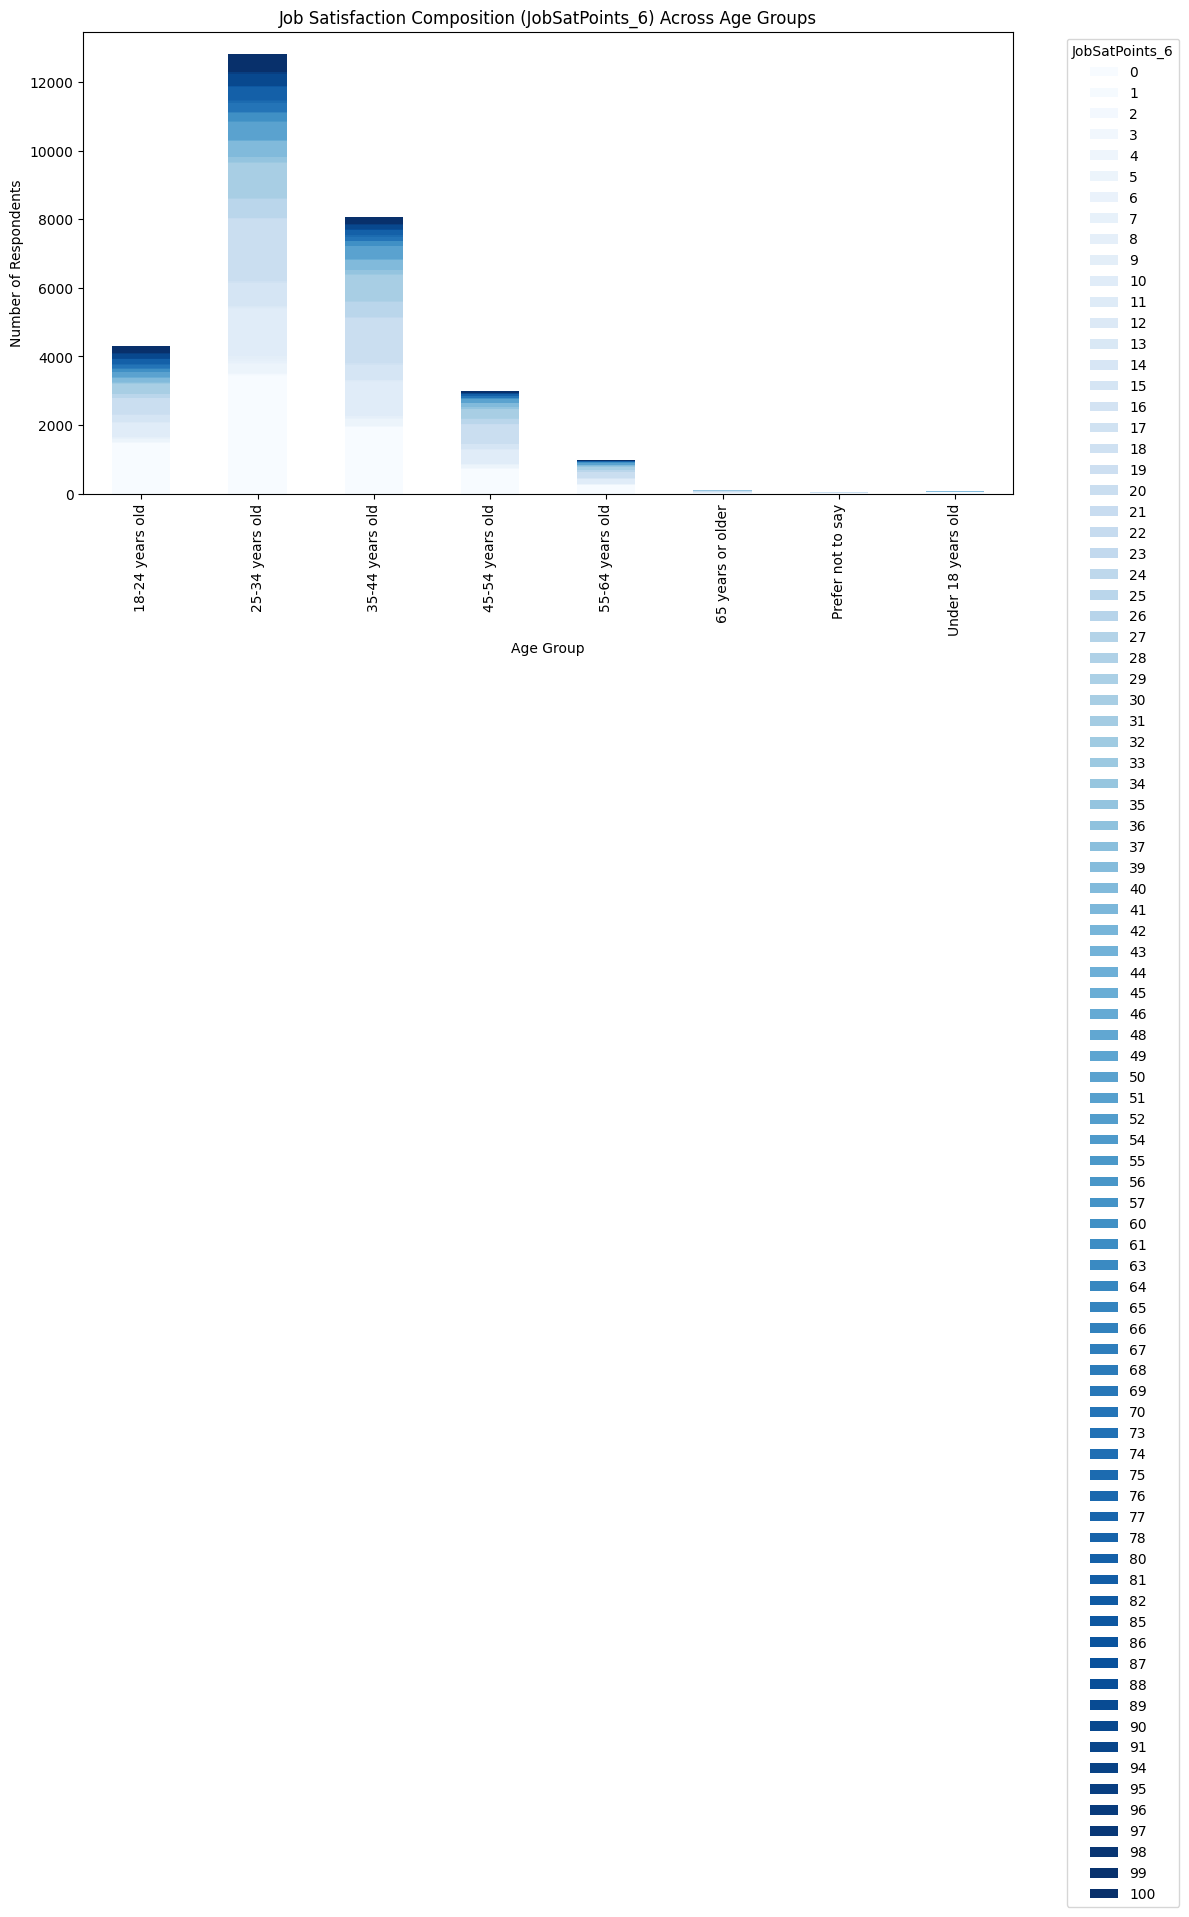

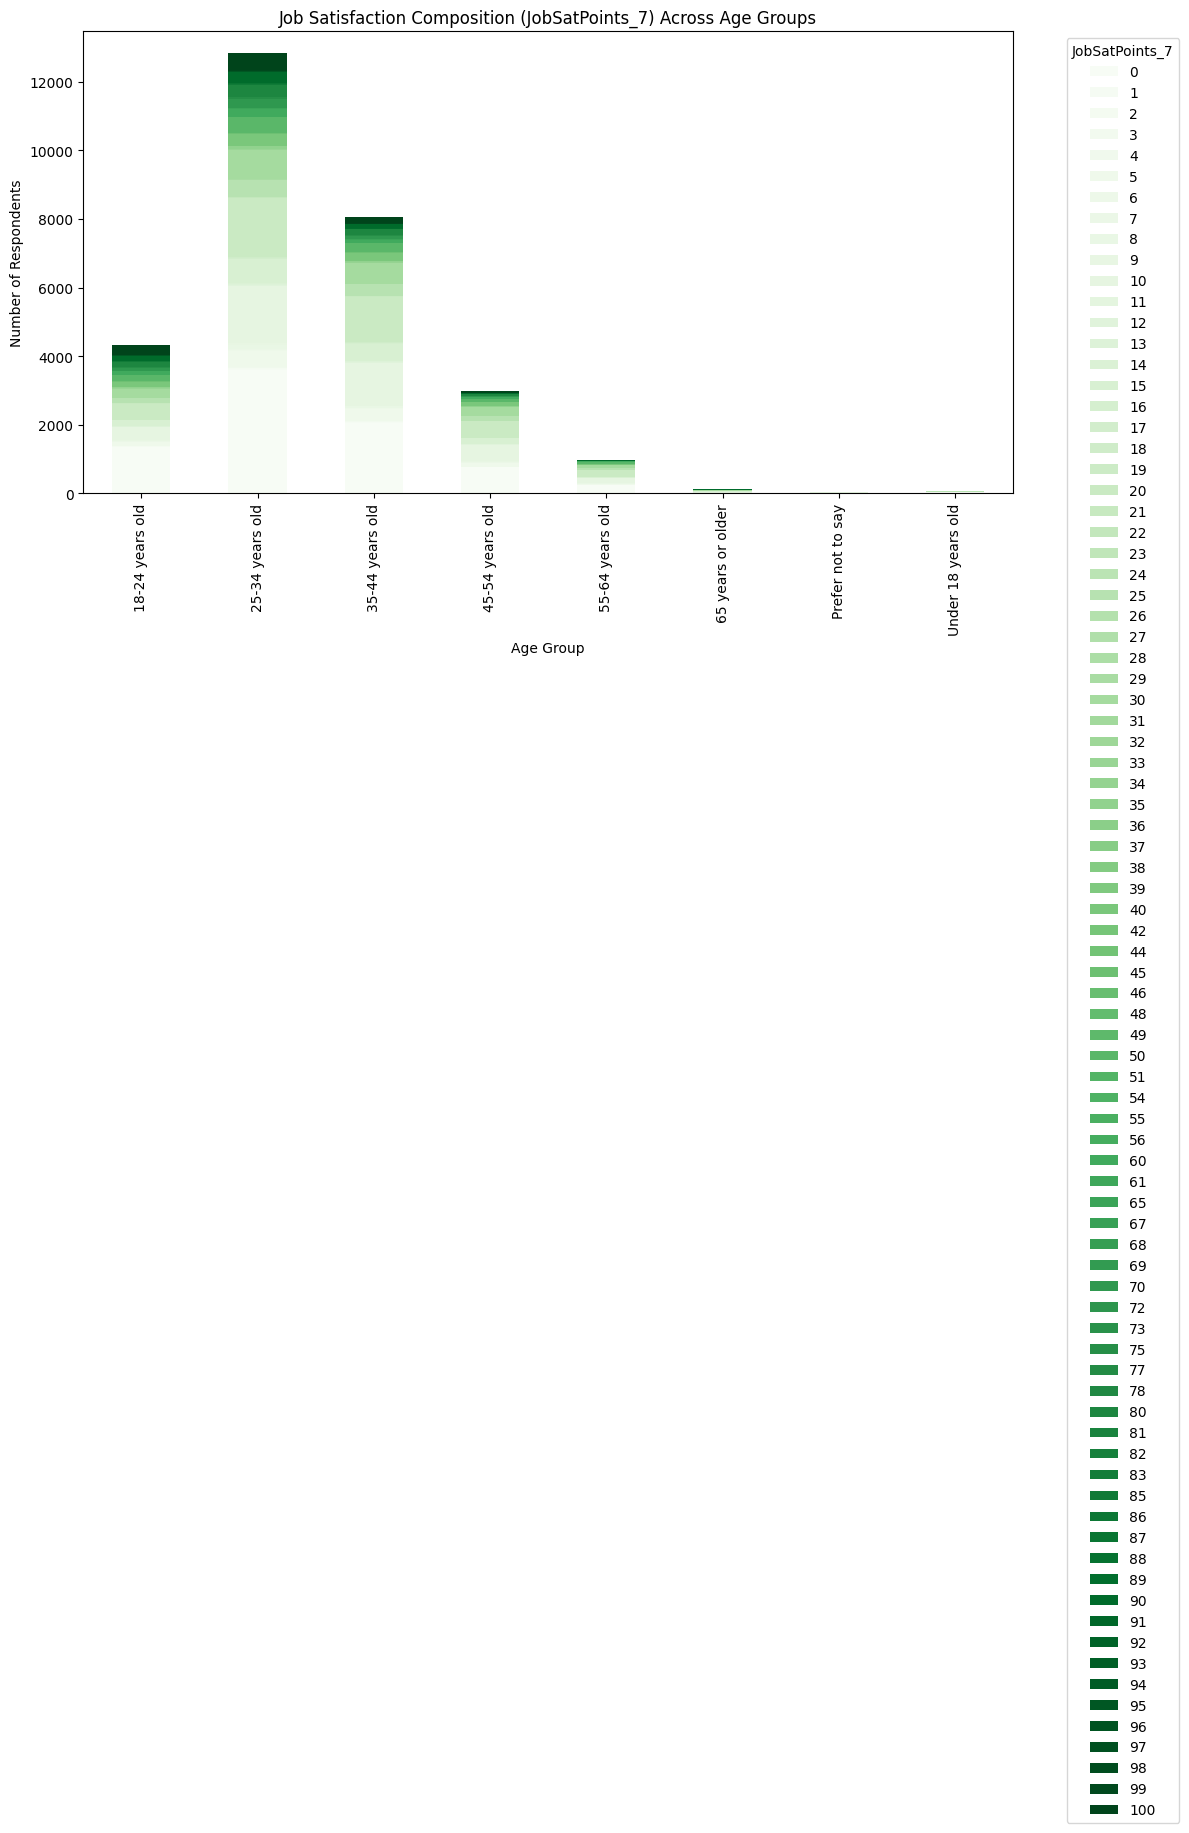

In [8]:
##Write your code here
# Keep relevant columns and drop missing values
sat_df = df[['Age', 'JobSatPoints_6', 'JobSatPoints_7']].dropna()

# Convert satisfaction scores to categorical (if numeric)
sat_df['JobSatPoints_6'] = sat_df['JobSatPoints_6'].astype(int)
sat_df['JobSatPoints_7'] = sat_df['JobSatPoints_7'].astype(int)
# Count satisfaction levels for JobSatPoints_6
sat6_counts = (
    sat_df.groupby(['Age', 'JobSatPoints_6'])
    .size()
    .unstack(fill_value=0)
)

# Count satisfaction levels for JobSatPoints_7
sat7_counts = (
    sat_df.groupby(['Age', 'JobSatPoints_7'])
    .size()
    .unstack(fill_value=0)
)
sat6_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='Blues'
)

plt.title('Job Satisfaction Composition (JobSatPoints_6) Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Respondents')
plt.legend(title='JobSatPoints_6', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

sat7_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='Greens'
)

plt.title('Job Satisfaction Composition (JobSatPoints_7) Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Respondents')
plt.legend(title='JobSatPoints_7', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


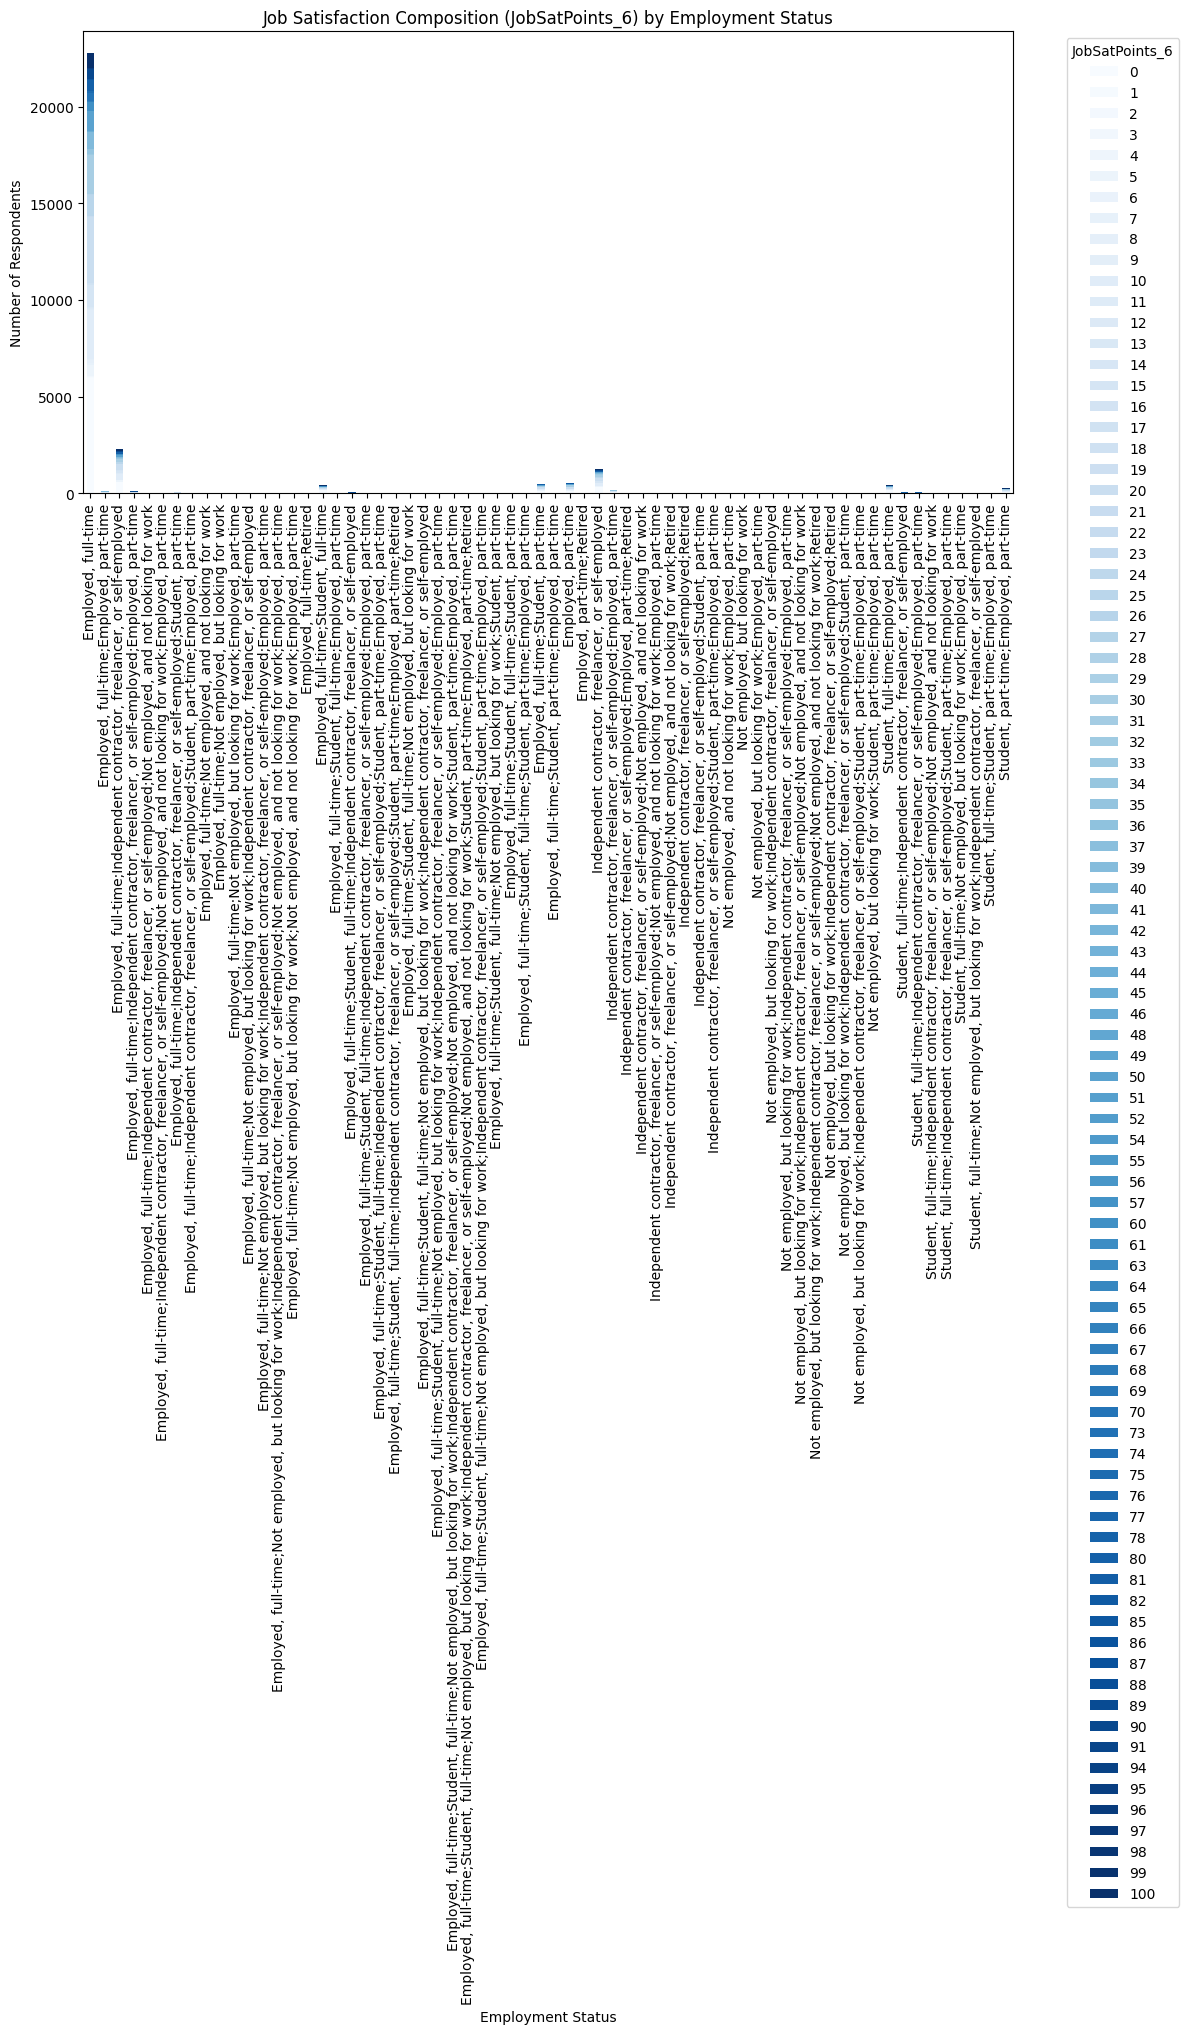

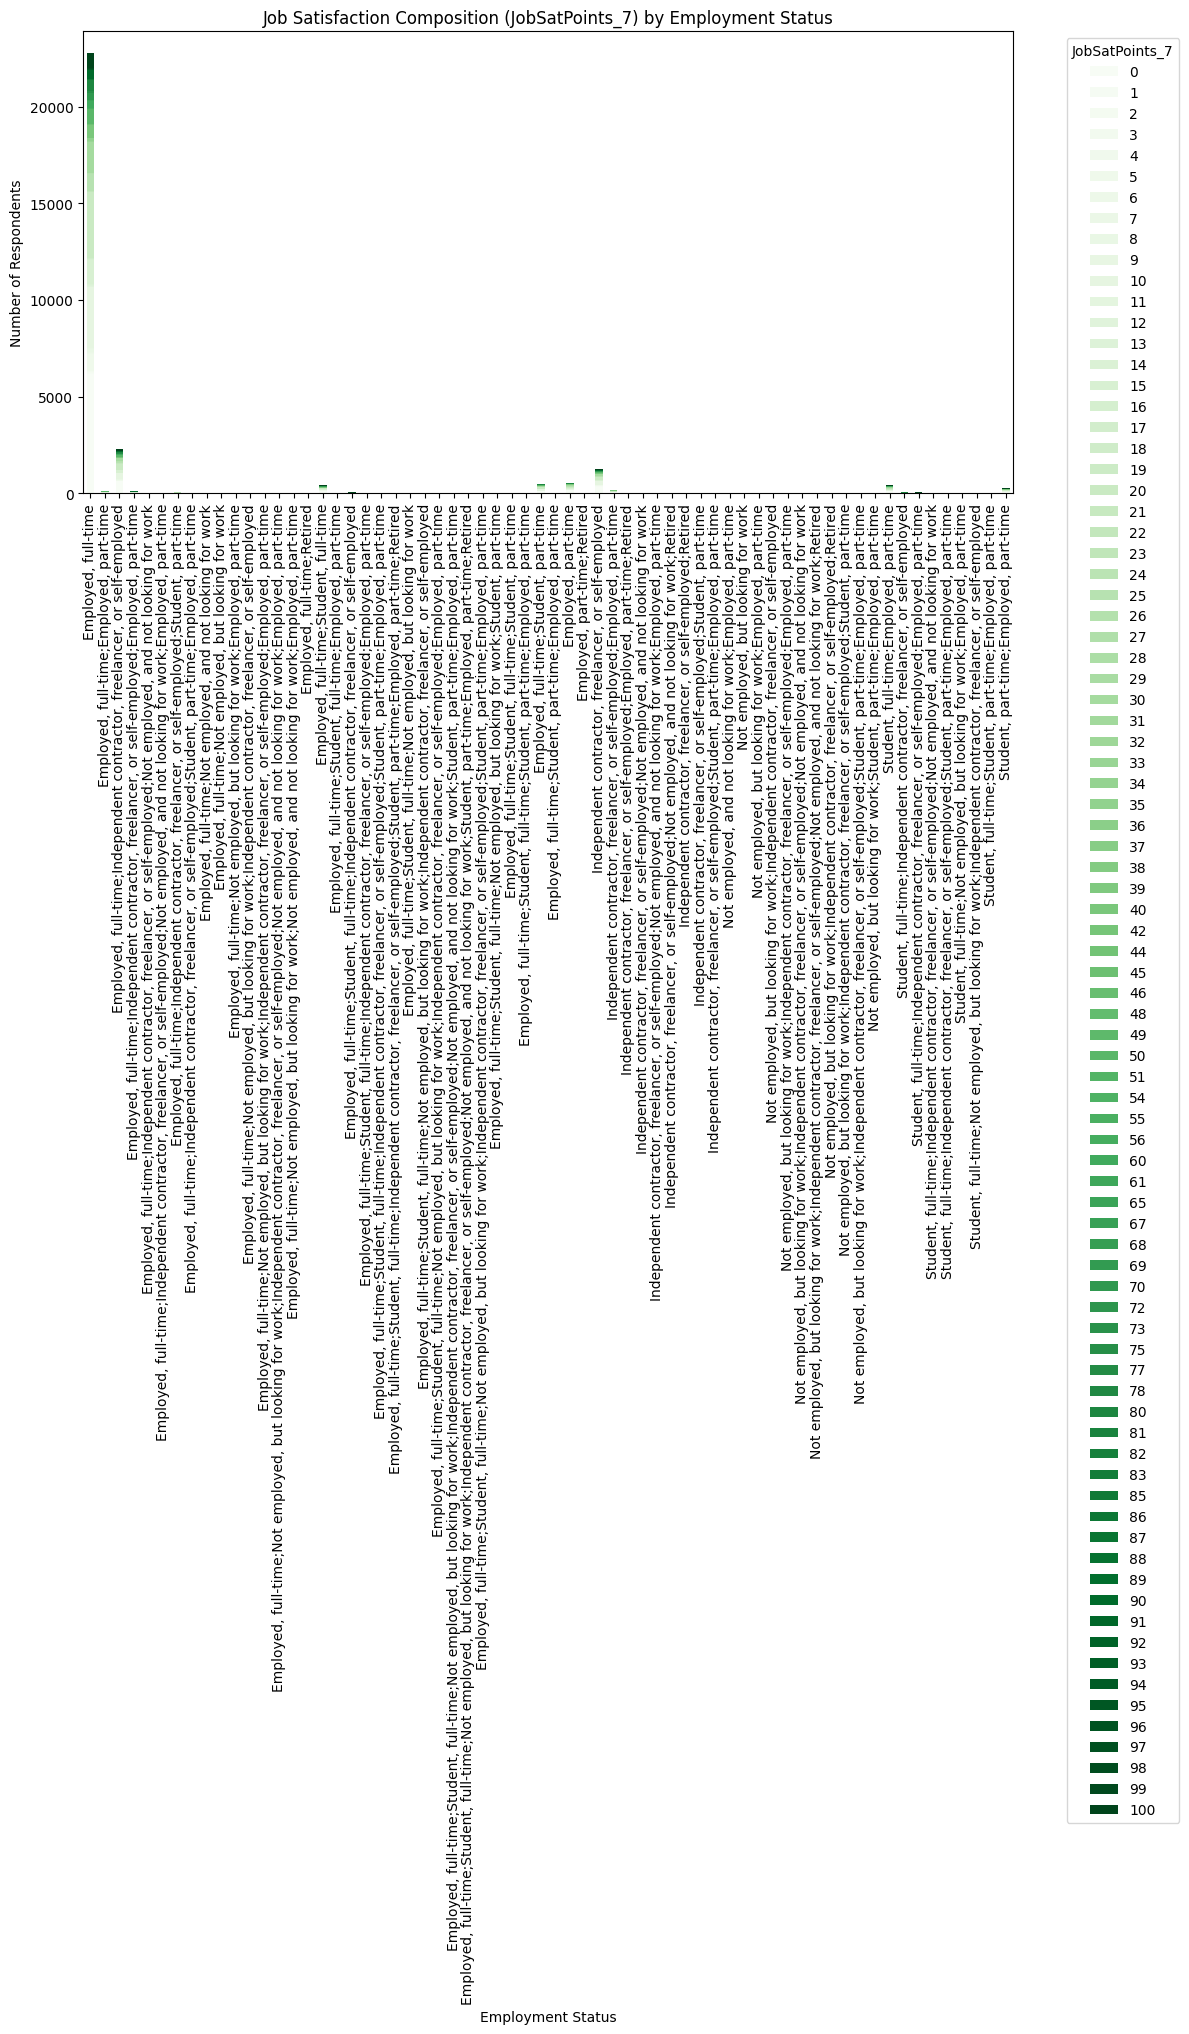

In [10]:
##Write your code here
# Select relevant columns and drop missing values
sat_emp = df[['Employment', 'JobSatPoints_6', 'JobSatPoints_7']].dropna()

# Convert satisfaction scores to integers (if needed)
sat_emp['JobSatPoints_6'] = sat_emp['JobSatPoints_6'].astype(int)
sat_emp['JobSatPoints_7'] = sat_emp['JobSatPoints_7'].astype(int)
sat6_emp = (
    sat_emp.groupby(['Employment', 'JobSatPoints_6'])
    .size()
    .unstack(fill_value=0)
)
sat7_emp = (
    sat_emp.groupby(['Employment', 'JobSatPoints_7'])
    .size()
    .unstack(fill_value=0)
)
sat6_emp.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='Blues'
)

plt.title('Job Satisfaction Composition (JobSatPoints_6) by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Number of Respondents')
plt.legend(title='JobSatPoints_6', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

sat7_emp.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='Greens'
)

plt.title('Job Satisfaction Composition (JobSatPoints_7) by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Number of Respondents')
plt.legend(title='JobSatPoints_7', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


Rows: 11808
Unique comp values: 3922
Stacked table shape: (4, 75)


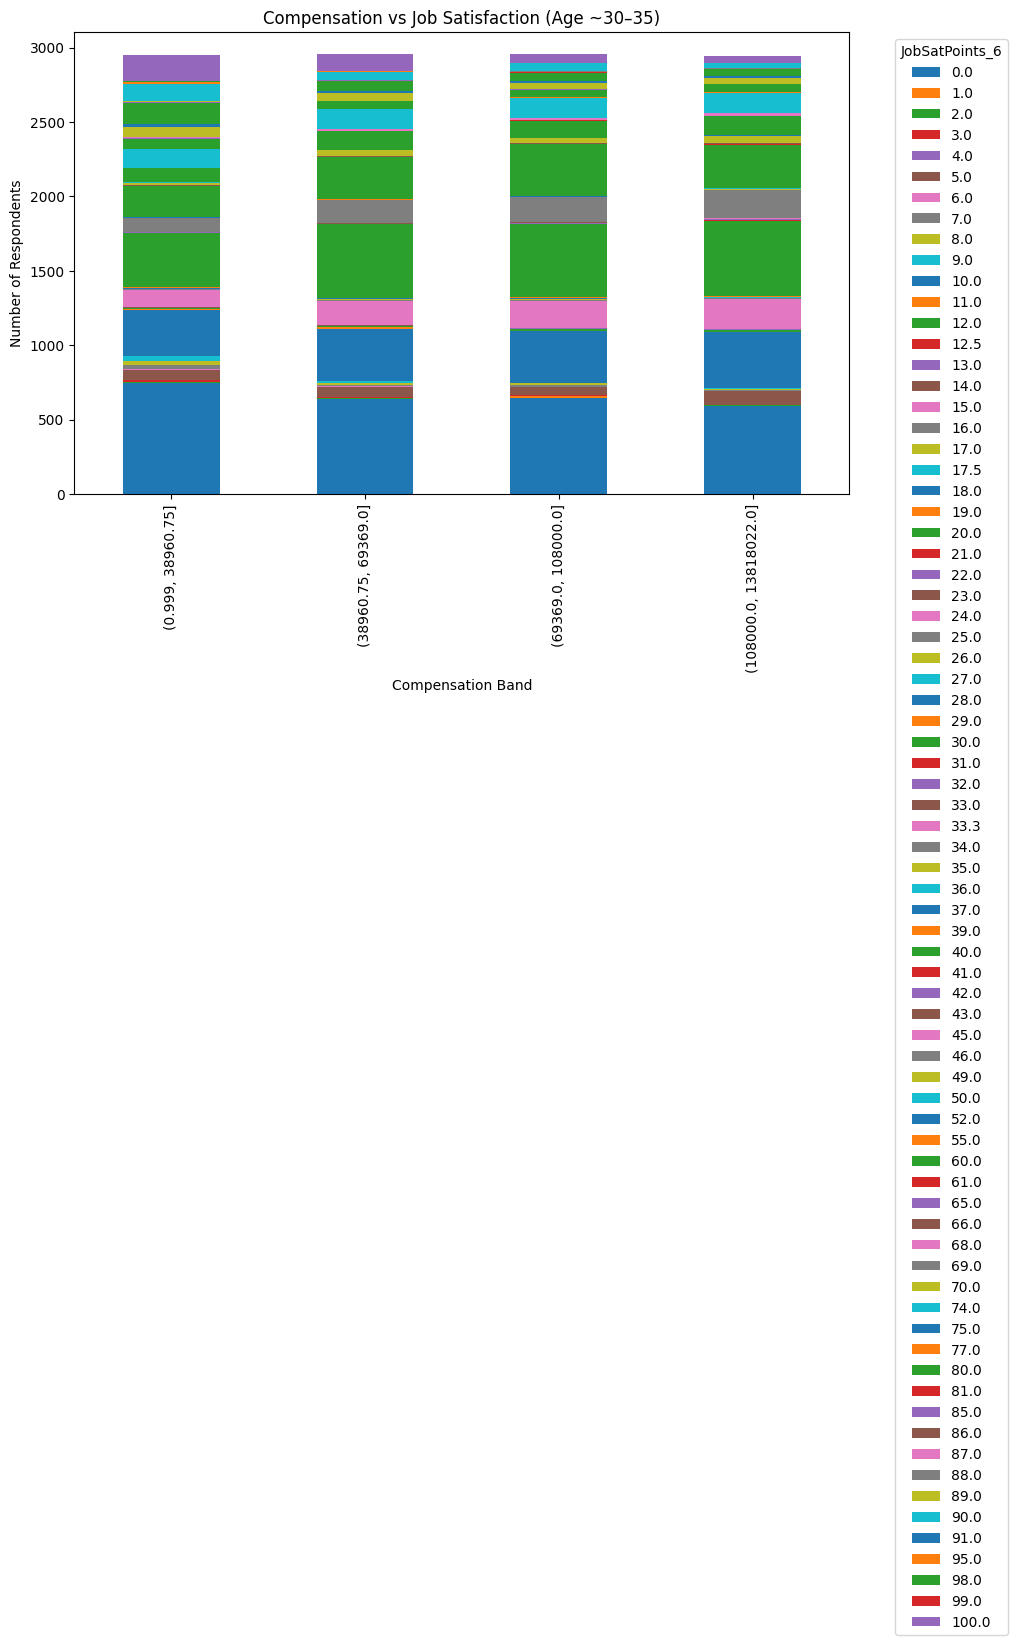

In [21]:
##Write your code here

# 1) Filter age group (closest match to "30–35" in your dataset)
age_30_35 = df[df['Age'].isin(['25-34 years old', '35-44 years old'])][
    ['ConvertedCompYearly', 'JobSatPoints_6']
].copy()

# 2) Drop NaNs
age_30_35 = age_30_35.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6'])



# 3) Create compensation bands safely (ONLY ONCE)
if age_30_35['ConvertedCompYearly'].nunique() < 4:
    age_30_35['CompBand'] = pd.cut(age_30_35['ConvertedCompYearly'], bins=4)
else:
    age_30_35['CompBand'] = pd.qcut(age_30_35['ConvertedCompYearly'], q=4, duplicates='drop')

# 4) Aggregate for stacked chart
stack_data = (
    age_30_35
    .groupby(['CompBand', 'JobSatPoints_6',],observed=True)
    .size()
    .unstack(fill_value=0)
)

print("Stacked table shape:", stack_data.shape)  # should NOT be (0, 0)

# 5) PLOT (this is the missing part in your code)
ax = stack_data.plot(kind='bar', stacked=True, figsize=(10, 6))

ax.set_title('Compensation vs Job Satisfaction (Age ~30–35)')
ax.set_xlabel('Compensation Band')
ax.set_ylabel('Number of Respondents')
ax.legend(title='JobSatPoints_6', bbox_to_anchor=(1.05, 1), loc='upper left')


plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


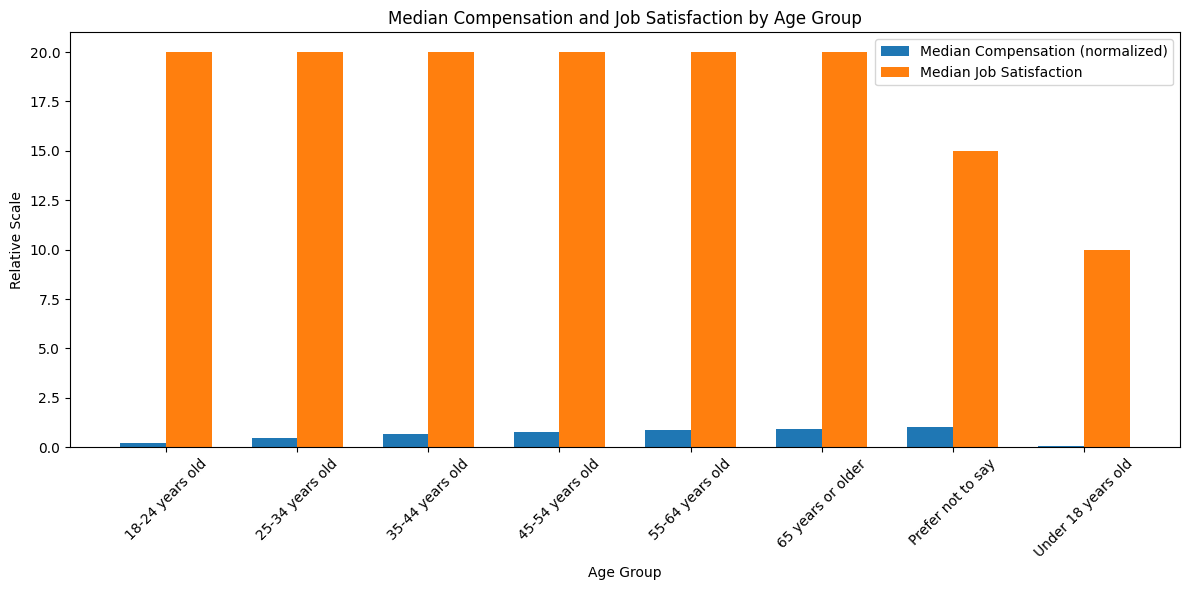

In [24]:
##Write your code here
# Keep relevant columns and drop missing values
comp_sat = df[['Age', 'ConvertedCompYearly', 'JobSatPoints_6']].dropna()

# Aggregate medians by age group
summary = (
    comp_sat
    .groupby('Age', observed=True)
    .agg(
        Median_Compensation=('ConvertedCompYearly', 'median'),
        Median_JobSatisfaction=('JobSatPoints_6', 'median')
    )
    .reset_index()
)
# Normalize compensation for visual comparison
summary['Norm_Comp'] = (
    summary['Median_Compensation'] / summary['Median_Compensation'].max()
)

x = np.arange(len(summary))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, summary['Norm_Comp'], width, label='Median Compensation (normalized)')
plt.bar(x + width/2, summary['Median_JobSatisfaction'], width, label='Median Job Satisfaction')

plt.xticks(x, summary['Age'], rotation=45)
plt.xlabel('Age Group')
plt.ylabel('Relative Scale')
plt.title('Median Compensation and Job Satisfaction by Age Group')
plt.legend()
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


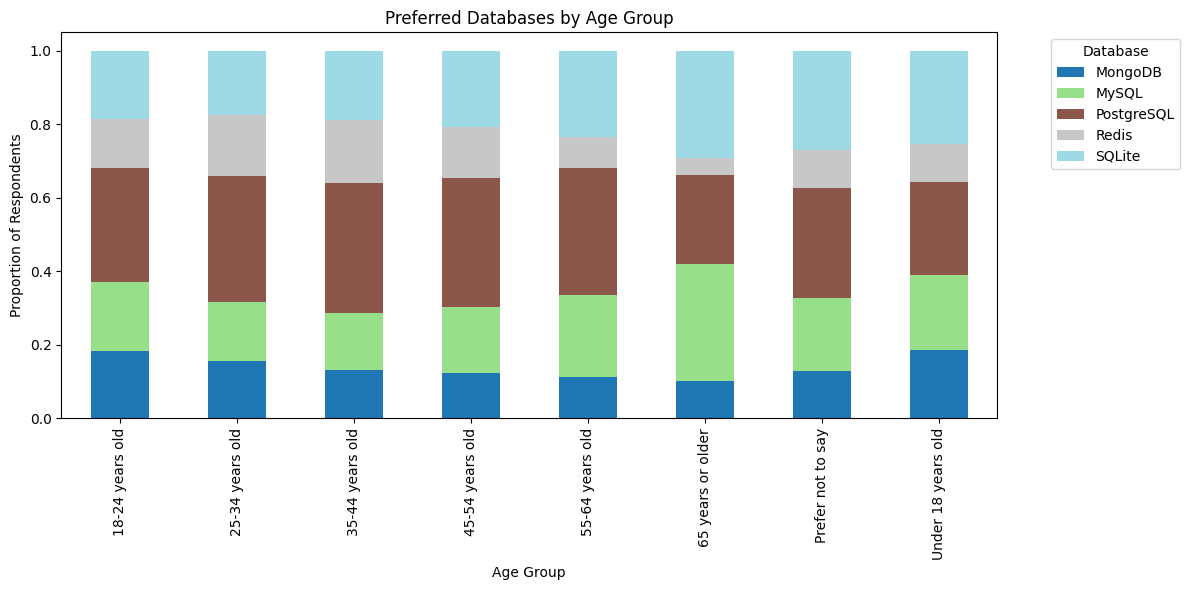

In [25]:
##Write your code here

# Keep relevant columns and drop missing values
db_df = df[['Age', 'DatabaseWantToWorkWith']].dropna()

# Split multiple databases into separate rows
db_df = db_df.assign(
    DatabaseWantToWorkWith=db_df['DatabaseWantToWorkWith'].str.split(';')
).explode('DatabaseWantToWorkWith')

##select Top Databases (Keeps Chart Readable)
top_dbs = (
    db_df['DatabaseWantToWorkWith']
    .value_counts()
    .head(5)
    .index
)

db_df = db_df[db_df['DatabaseWantToWorkWith'].isin(top_dbs)]

##Aggregate Counts by Age Group and Database
stack_data = (
    db_df
    .groupby(['Age', 'DatabaseWantToWorkWith'], observed=True)
    .size()
    .unstack(fill_value=0)
)
##Convert Counts to Proportions (Percentages)
stack_pct = stack_data.div(stack_data.sum(axis=1), axis=0)

##Stacked Bar Chart
stack_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='tab20'
)

plt.title('Preferred Databases by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion of Respondents')
plt.legend(title='Database', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


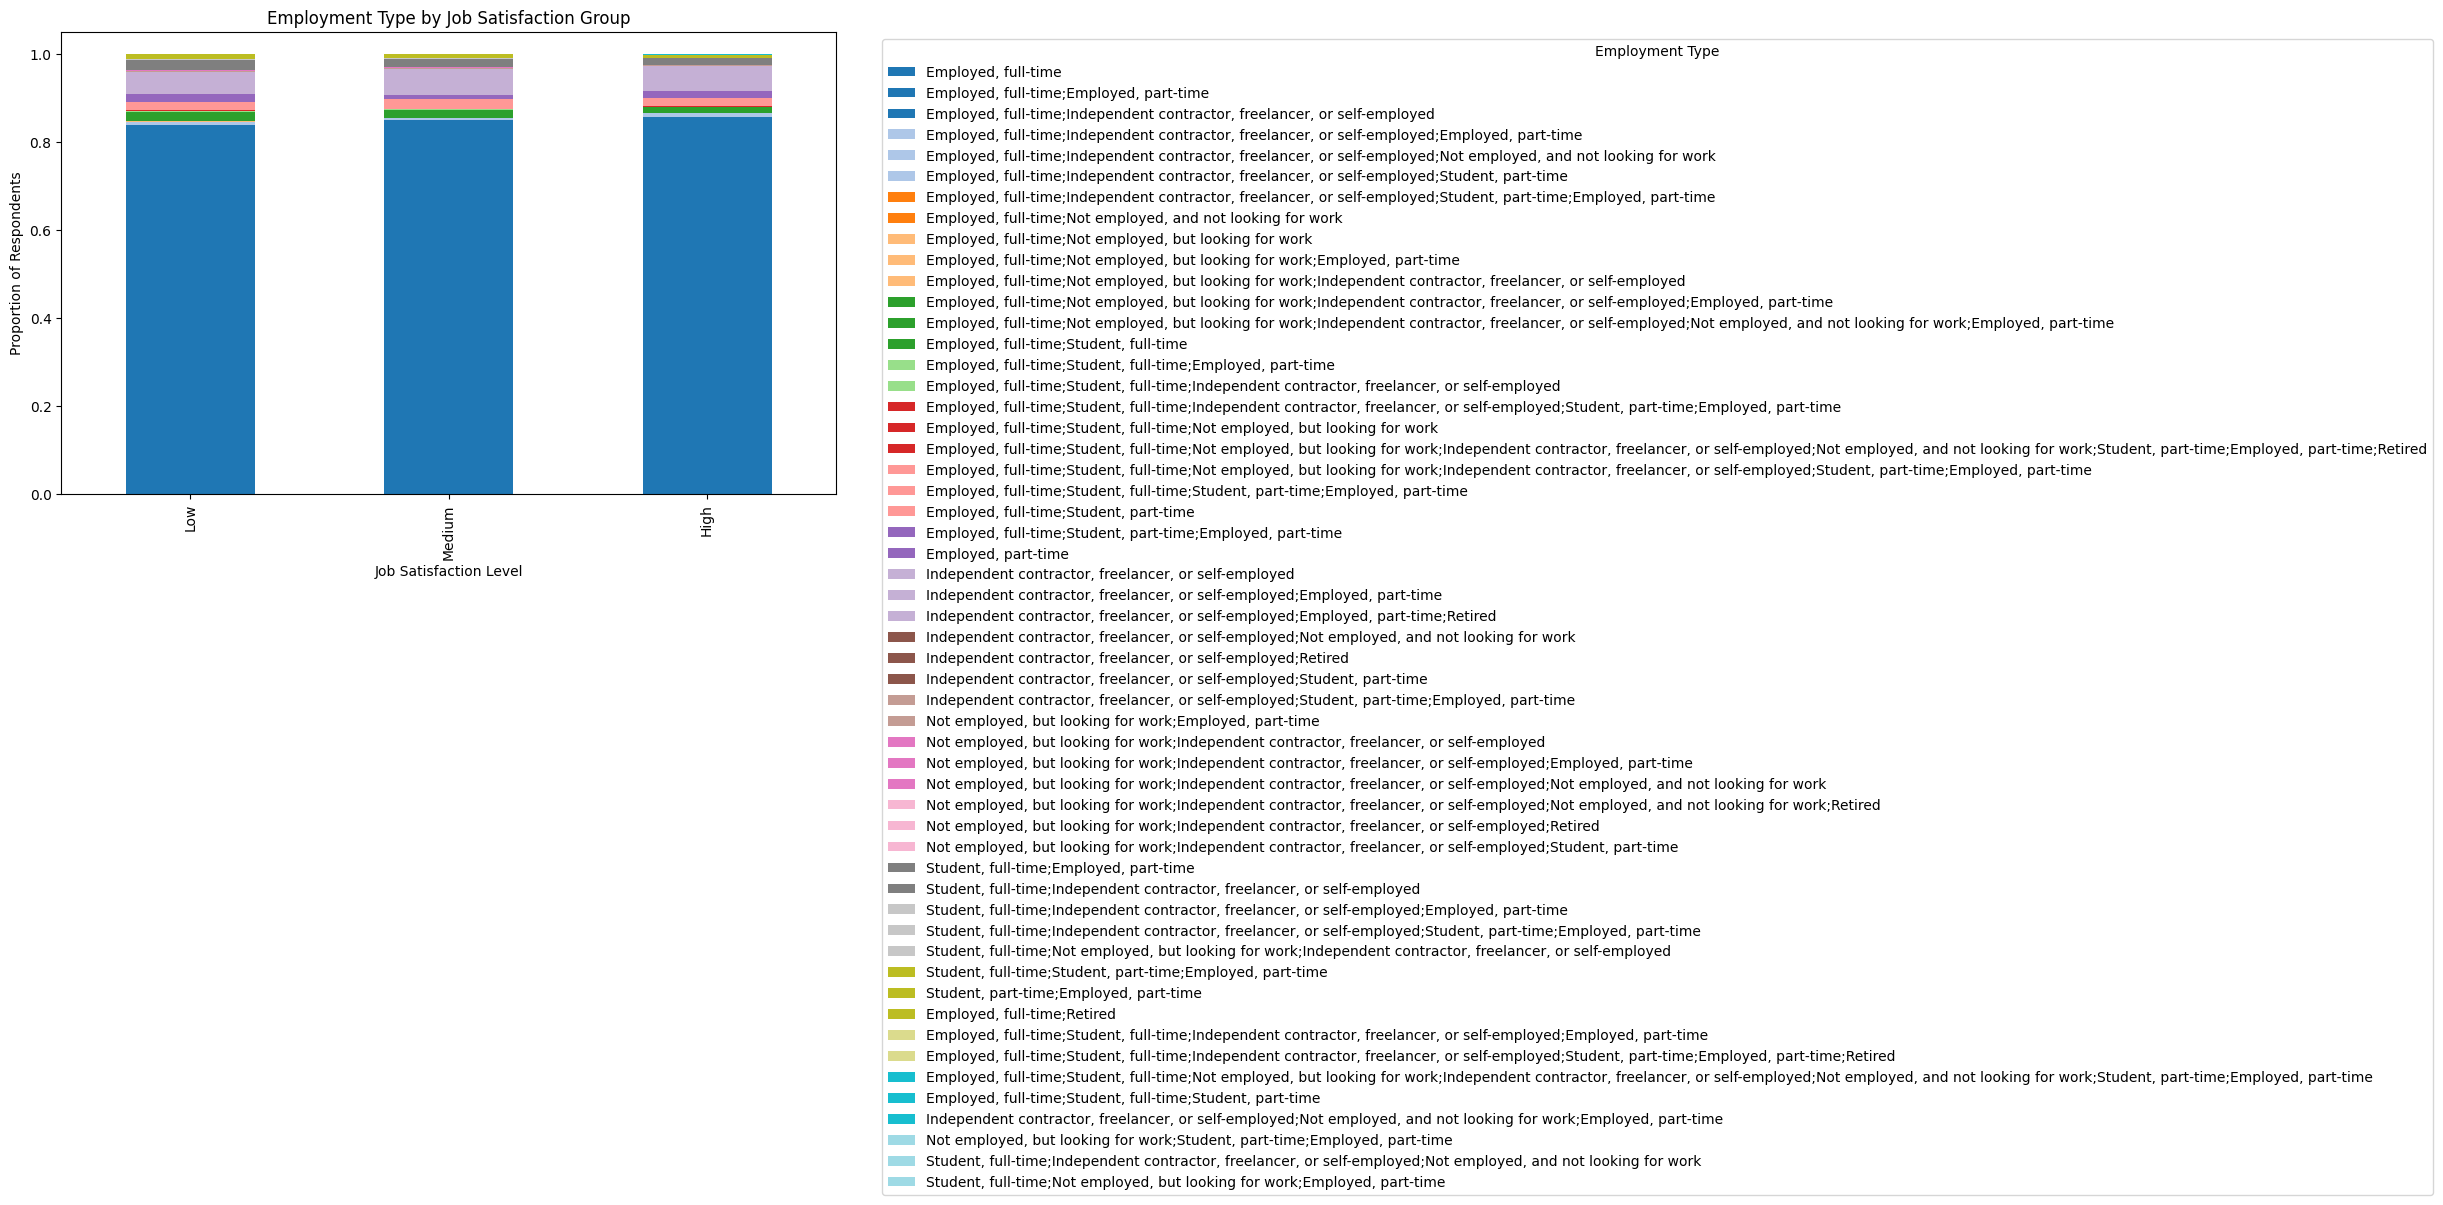

In [29]:
##Write your code here

# Keep relevant columns and drop missing values
emp_sat = df[['Employment', 'JobSatPoints_6']].dropna()

# Ensure JobSatPoints_6 is treated as a category or int
emp_sat['JobSatPoints_6'] = emp_sat['JobSatPoints_6'].astype(int)
# Create satisfaction bands
emp_sat['JobSatGroup'] = pd.cut(
    emp_sat['JobSatPoints_6'],
    bins=[-1, 3, 7, 10],
    labels=['Low', 'Medium', 'High']
)

stack_data = (
    emp_sat
    .groupby(['JobSatGroup', 'Employment'], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Convert to proportions
stack_pct = stack_data.div(stack_data.sum(axis=1), axis=0)

stack_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='tab20'
)

plt.title('Employment Type by Job Satisfaction Group')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Proportion of Respondents')
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
##Full-time employees appear across low, medium, and high satisfaction groups because they make up the majority of survey respondents. 
##The stacked chart shows proportions within each satisfaction level rather than absolute counts. While full-time employment dominates all groups, 
##the high satisfaction category has a slightly higher concentration of full-time workers, 
##suggesting that stable employment may be associated with higher satisfaction, but it is not the sole determining factor

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


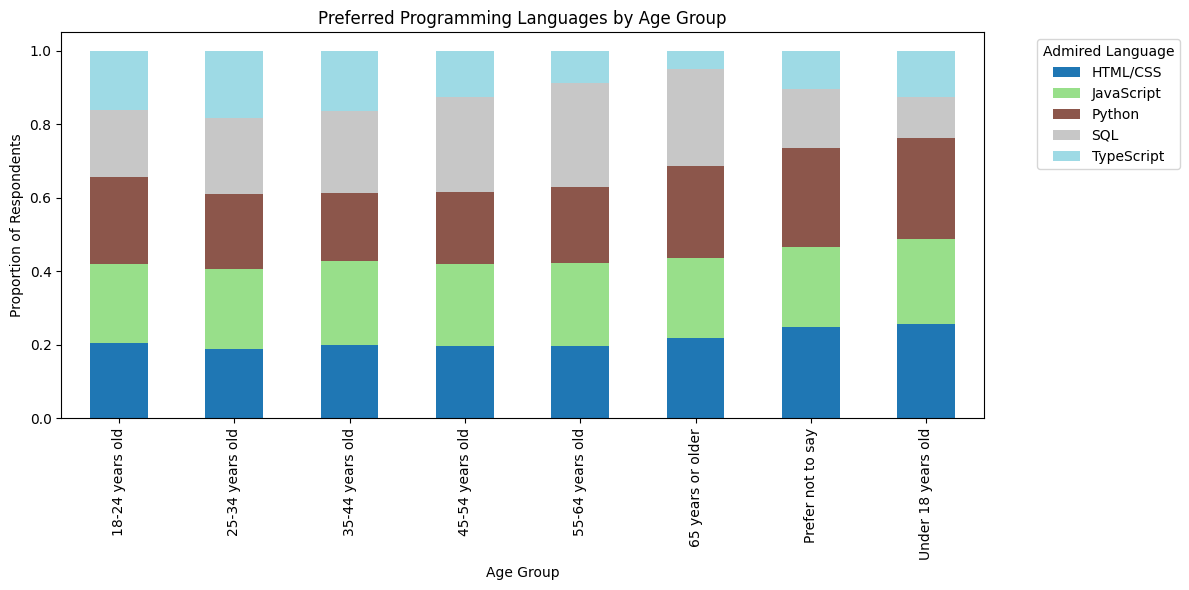

In [30]:
##Write your code here
# Keep relevant columns and drop missing values
lang_df = df[['Age', 'LanguageAdmired']].dropna()

# Split multiple admired languages into rows
lang_df['LanguageAdmired'] = lang_df['LanguageAdmired'].str.split(';')
lang_df = lang_df.explode('LanguageAdmired')
top_languages = (
    lang_df['LanguageAdmired']
    .value_counts()
    .head(5)
    .index
)

lang_df = lang_df[lang_df['LanguageAdmired'].isin(top_languages)]
stack_data = (
    lang_df
    .groupby(['Age', 'LanguageAdmired'], observed=True)
    .size()
    .unstack(fill_value=0)
)
stack_pct = stack_data.div(stack_data.sum(axis=1), axis=0)
stack_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='tab20'
)

plt.title('Preferred Programming Languages by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion of Respondents')
plt.legend(title='Admired Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
##Programming language admiration is broadly consistent across age groups, with JavaScript and Python leading, while older age groups show more diversified preferences.

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


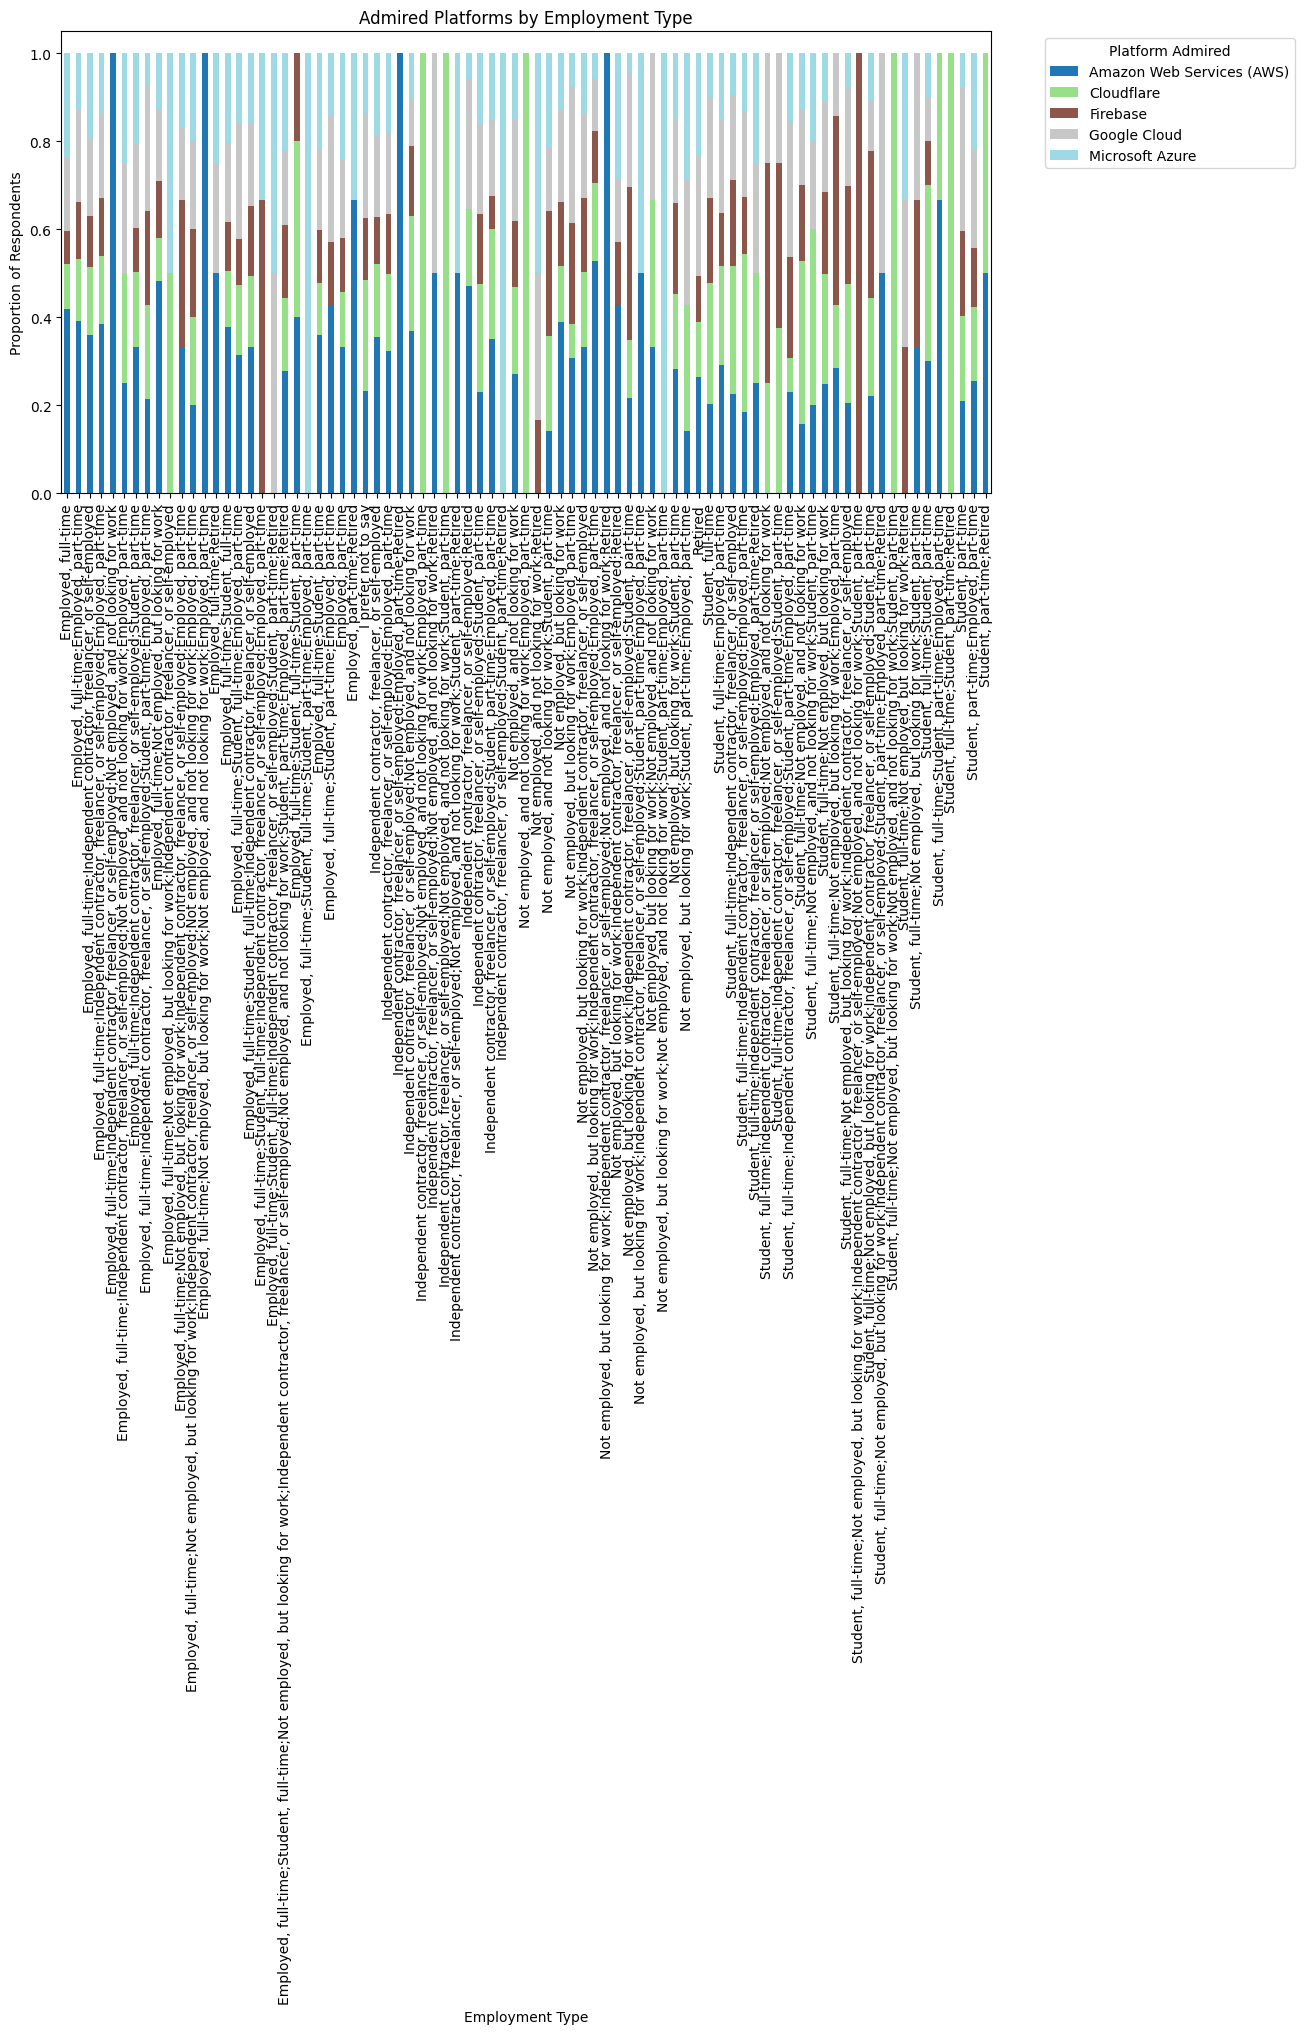

In [32]:
##Write your code here
# Keep relevant columns and drop missing values
plat_df = df[['Employment', 'PlatformAdmired']].dropna()

# Split multiple platforms into separate rows
plat_df['PlatformAdmired'] = plat_df['PlatformAdmired'].str.split(';')
plat_df = plat_df.explode('PlatformAdmired')
top_platforms = (
    plat_df['PlatformAdmired']
    .value_counts()
    .head(5)
    .index
)

plat_df = plat_df[plat_df['PlatformAdmired'].isin(top_platforms)]
##Aggregate by Employment Type and Platform
stack_data = (
    plat_df
    .groupby(['Employment', 'PlatformAdmired'], observed=True)
    .size()
    .unstack(fill_value=0)
)
##Convert Counts to Proportions
stack_pct = stack_data.div(stack_data.sum(axis=1), axis=0)
stack_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='tab20'
)

plt.title('Admired Platforms by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Proportion of Respondents')
plt.legend(title='Platform Admired', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
